### Robustez e interpretabilidade — idade em EO (SVM-RBF)

Análise principal após screening (`07`) e permutação (`08`):

- **Tarefa / modelo / métrica:** EO · SVM-RBF (`class_weight="balanced"`) · ROC-AUC
- **Features:** alinhadas por **nome de eletrodo** (`betweenness_Oz`, …), cobertura ≥95% EO&EC (53 eletrodos; 215 features com as 3 globais); ver `00_redes/03_realign_features_by_electrode.ipynb`
- **Scores ROC:** `decision_function`
- **Importância:** permutation nos folds de **teste**
- **PCA:** exploração/redundância no TCC; modelo principal **sem** PCA

Screening / permutação: `07` e `08`.


### Imports


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

### Parâmetros e dados (EO)


In [ ]:
DATASET_PATH = Path("../../data/processed/dataset_features.parquet")
RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 20
N_PERM_IMPORTANCE = 100
TOP_K_FEATURES = 8
META_COLS = ["gender", "education"]
EDUCATION_FIX = {"gymansium": "gymnasium"}

YOUNG_AGES = {"20-25", "25-30", "30-35", "35-40"}
OLDER_AGES = {"55-60", "60-65", "65-70", "70-75", "75-80"}

NODE_PREFIXES = (
    "degree_",
    "clustering_",
    "betweenness_",
    "hub_frequency_",
)
GLOBAL_FEATURES = [
    "edges_mean",
    "edges_std",
    "edges_cv",
]
FEATURE_FAMILIES = {
    "degree": ("degree_",),
    "clustering": ("clustering_",),
    "betweenness": ("betweenness_",),
    "hub_frequency": ("hub_frequency_",),
    "global": tuple(GLOBAL_FEATURES),
}


def map_age_group(age: str):
    if age in YOUNG_AGES:
        return "young"
    if age in OLDER_AGES:
        return "older"
    return None


def normalize_education(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().replace(EDUCATION_FIX)


def make_svm():
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                SVC(
                    kernel="rbf",
                    class_weight="balanced",
                    probability=False,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def electrode_region(name: str) -> str:
    n = name.upper()
    for prefix, region in (
        ("FP", "frontal_polar"),
        ("AF", "anterior_frontal"),
        ("FT", "fronto_temporal"),
        ("FC", "fronto_central"),
        ("TP", "temporo_parietal"),
        ("CP", "centro_parietal"),
        ("PO", "parieto_occipital"),
        ("F", "frontal"),
        ("C", "central"),
        ("T", "temporal"),
        ("P", "parietal"),
        ("O", "occipital"),
    ):
        if n.startswith(prefix):
            return region
    return "other"


df = pd.read_parquet(DATASET_PATH)
eo = df[df["condition"] == "EO"].copy()
duplicated = eo.duplicated("subject_id", keep=False)
assert not duplicated.any(), (
    "Foram encontrados subject_id duplicados na condição EO: "
    f"{eo.loc[duplicated, 'subject_id'].tolist()}"
)
eo["age"] = eo["age"].astype(str)
eo["age_group"] = eo["age"].map(map_age_group)
eo = eo[eo["age_group"].notna()].copy()
eo["y"] = eo["age_group"].map({"young": 0, "older": 1}).astype(int)
eo["education"] = normalize_education(eo["education"])

FEATURE_COLS = [
    c
    for c in eo.columns
    if c.startswith(NODE_PREFIXES) or c in GLOBAL_FEATURES
]
FEATURE_COLS = (
    eo[FEATURE_COLS]
    .select_dtypes(include="number")
    .dropna(axis=1, how="all")
    .columns.tolist()
)

X = eo[FEATURE_COLS].copy()
y = eo["y"].copy()
X.index = eo["subject_id"].values
y.index = eo["subject_id"].values

named_bt = [c for c in FEATURE_COLS if c.startswith("betweenness_")]
assert named_bt and not named_bt[0].split("_", 1)[1].isdigit(), (
    "Dataset ainda parece indexado; rode notebook/00_redes/03_realign_features_by_electrode.ipynb"
)
print(
    f"EO: n={len(y)}, features={X.shape[1]}, y={y.value_counts().to_dict()}, "
    f"betweenness_nomeadas={len(named_bt)}"
)
print("education (após padronização):", sorted(eo["education"].unique()))
print("Exemplo de features:", named_bt[:5])

EO: n=54, features=215, y={0: 35, 1: 19}, betweenness_nomeadas=53
education (após padronização): ['gymnasium', 'realschule']
Exemplo de features: ['betweenness_AF3', 'betweenness_AF4', 'betweenness_AF8', 'betweenness_AFz', 'betweenness_C1']


### 1. Predições fora da amostra (CV 5-fold)

Scores com `decision_function` (mesmo tipo usado por `scoring="roc_auc"` no SVM). A matriz de confusão mostra o limiar de decisão; AUC alta ≠ classificação confiável.


In [ ]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
model = make_svm()

y_pred = cross_val_predict(model, X, y, cv=cv)
y_score = cross_val_predict(model, X, y, cv=cv, method="decision_function")

cm = confusion_matrix(y, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
sens_older = tp / (tp + fn) if (tp + fn) else np.nan
spec_young = tn / (tn + fp) if (tn + fp) else np.nan
bal = balanced_accuracy_score(y, y_pred)
auc = roc_auc_score(y, y_score)
fpr, tpr, _ = roc_curve(y, y_score)

oof_metrics = pd.DataFrame(
    [
        {
            "roc_auc": auc,
            "balanced_accuracy": bal,
            "sensitivity_older": sens_older,
            "specificity_young": spec_young,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    ]
)
oof_metrics

,roc_auc,balanced_accuracy,sensitivity_older,specificity_young,tn,fp,fn,tp
0,0.715789,0.699248,0.684211,0.714286,25,10,6,13


In [ ]:
fig_roc = go.Figure()
fig_roc.add_trace(
    go.Scatter(x=fpr, y=tpr, mode="lines", name=f"SVM ROC (AUC={auc:.3f})")
)
fig_roc.add_trace(
    go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="chance", line=dict(dash="dash"))
)
fig_roc.update_layout(
    title="Curva ROC OOF (EO, SVM-RBF, decision_function)",
    xaxis_title="1 − especificidade (FPR)",
    yaxis_title="Sensibilidade (TPR)",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    template="plotly_white",
    hovermode=False,
)
fig_roc.show(config={"displayModeBar": False})

fig_cm = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale="Blues",
    labels=dict(x="Predito", y="Verdadeiro", color="n"),
    x=["young (0)", "older (1)"],
    y=["young (0)", "older (1)"],
    title="Matriz de confusão OOF",
)
fig_cm.update_layout(template="plotly_white", hovermode=False)
fig_cm.show(config={"displayModeBar": False})

Figura salva em ..\..\figures\fig_svm_roc_confusao_ab.png


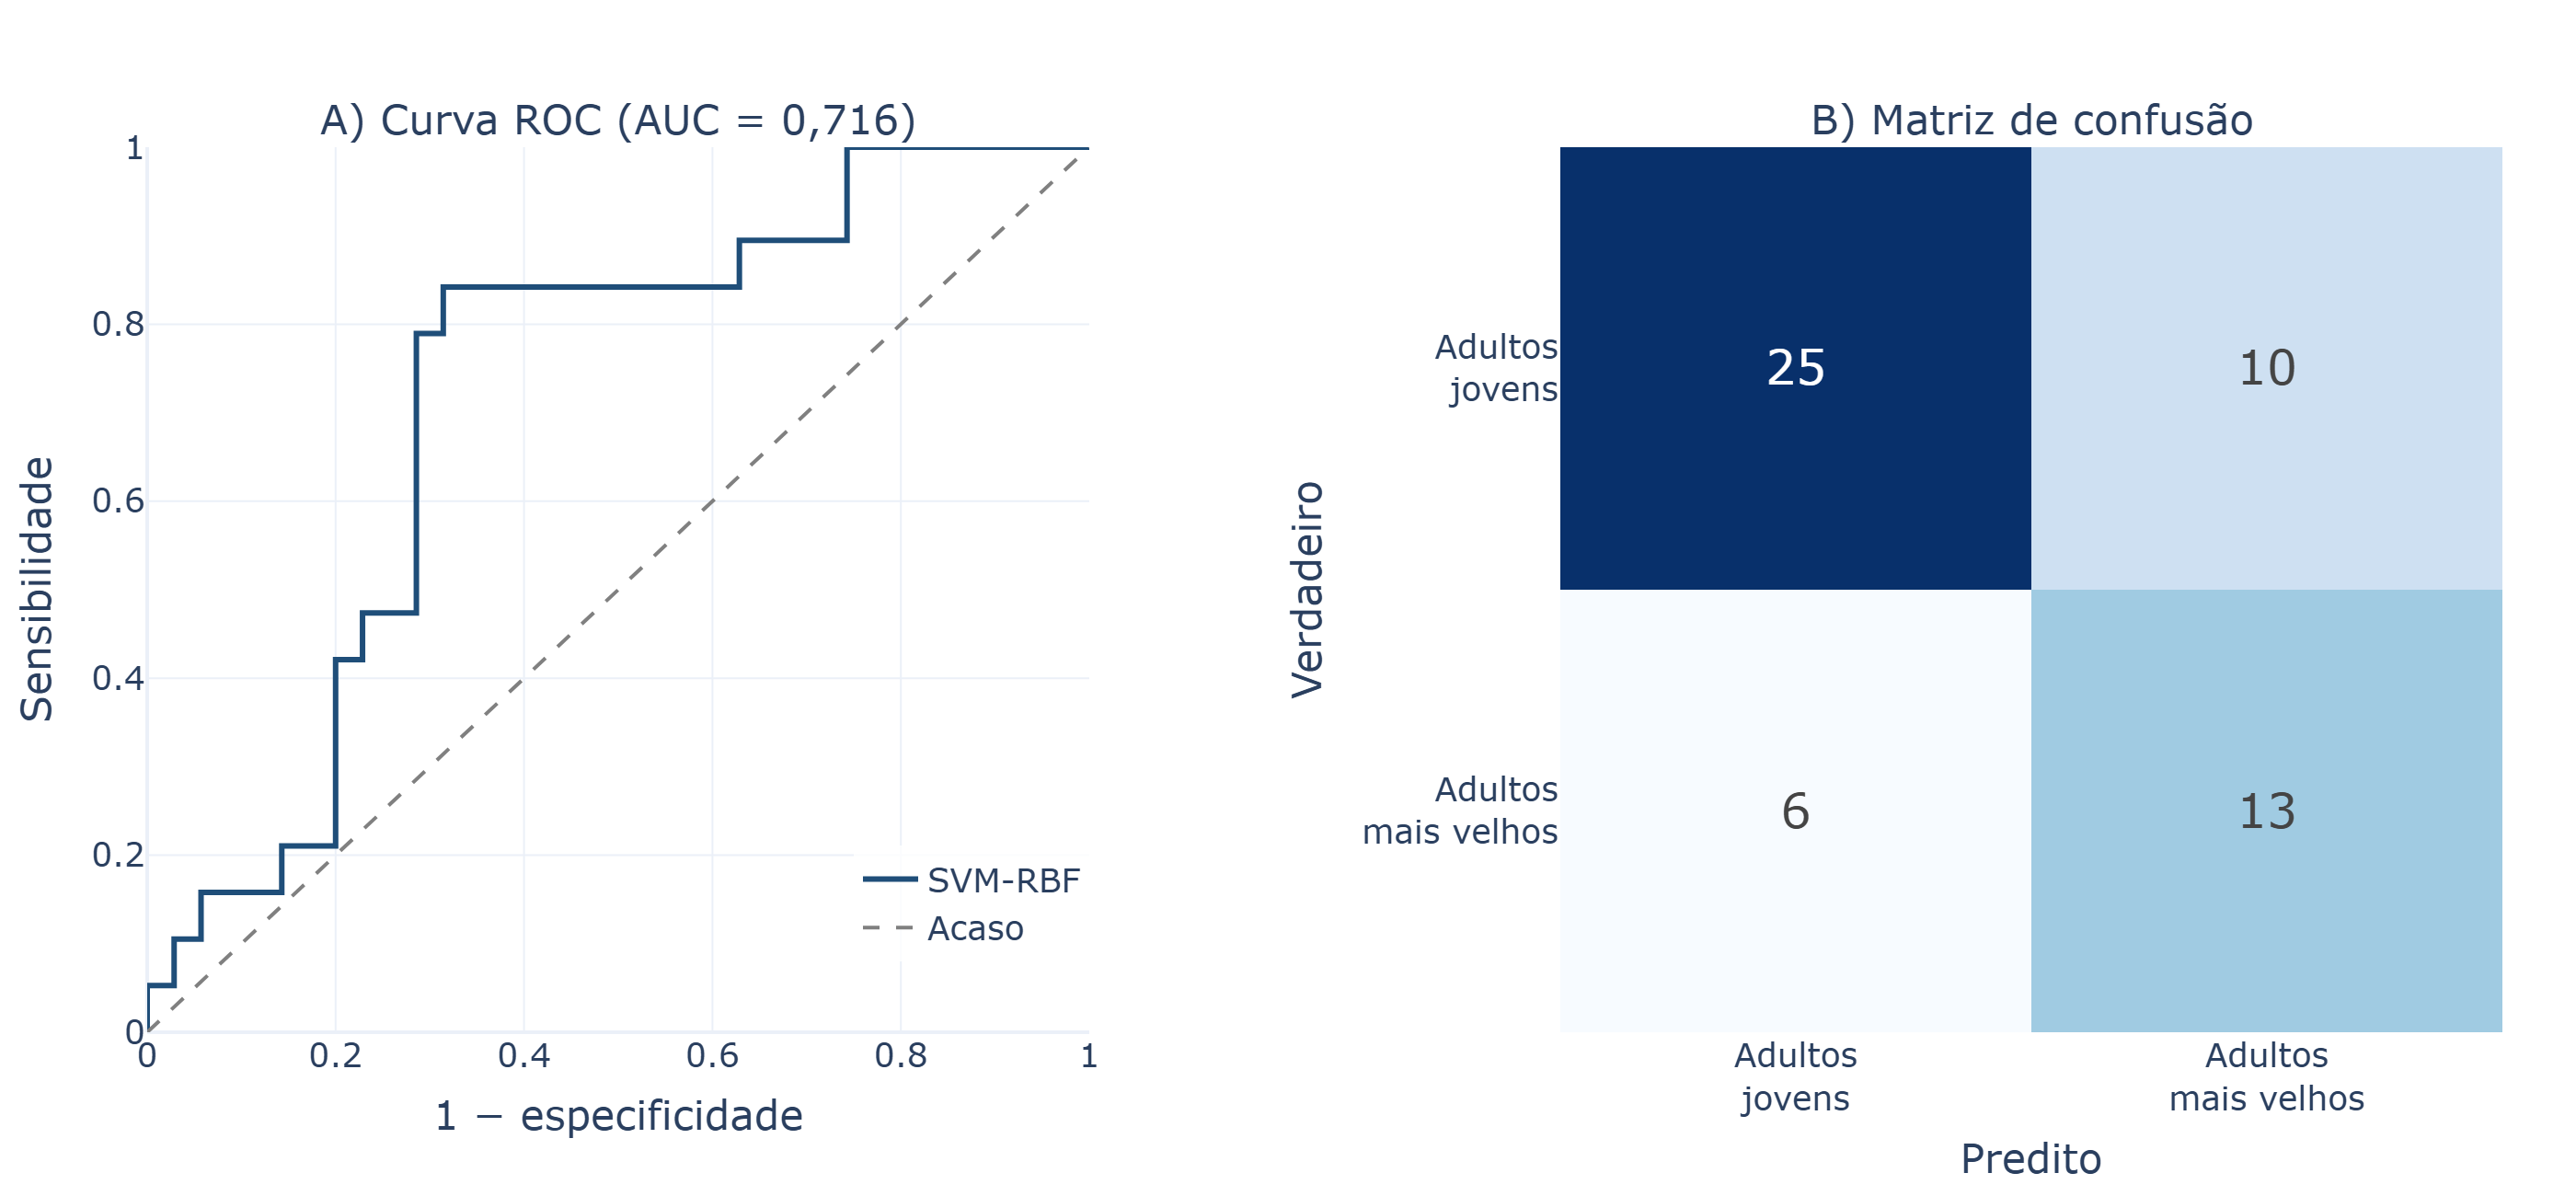

In [ ]:
from pathlib import Path

from IPython.display import Image, display
from plotly.subplots import make_subplots

CLASS_LABELS = ["Adultos<br>jovens", "Adultos<br>mais velhos"]

fig_ab = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.2,
    subplot_titles=(
        f"A) Curva ROC (AUC = {auc:.3f})".replace(".", ","),
        "B) Matriz de confusão",
    ),
)

fig_ab.add_trace(
    go.Scatter(x=fpr, y=tpr, mode="lines", name="SVM-RBF", line=dict(color="#1f4e79", width=3)),
    row=1,
    col=1,
)
fig_ab.add_trace(
    go.Scatter(
        x=[0, 1], y=[0, 1], mode="lines", name="Acaso", line=dict(color="gray", dash="dash", width=2)
    ),
    row=1,
    col=1,
)

fig_ab.add_trace(
    go.Heatmap(
        z=cm,
        x=CLASS_LABELS,
        y=CLASS_LABELS,
        text=cm,
        texttemplate="%{text}",
        textfont=dict(size=26),
        colorscale="Blues",
        showscale=False,
    ),
    row=1,
    col=2,
)

fig_ab.update_xaxes(title_text="1 − especificidade", range=[0, 1], row=1, col=1)
fig_ab.update_yaxes(title_text="Sensibilidade", range=[0, 1], row=1, col=1)
fig_ab.update_xaxes(title_text="Predito", row=1, col=2)
fig_ab.update_yaxes(title_text="Verdadeiro", autorange="reversed", row=1, col=2)
fig_ab.update_annotations(font_size=22)
fig_ab.update_layout(
    template="plotly_white",
    height=650,
    font=dict(size=18),
    legend=dict(x=0.3, y=0.08, bgcolor="rgba(255,255,255,0.8)"),
    hovermode=False,
    margin=dict(l=80, r=40, t=80, b=80),
)
fig_path = Path("../../figures/fig_svm_roc_confusao_ab.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
try:
    fig_ab.write_image(fig_path, width=1400, height=650, scale=2)
    print(f"Figura salva em {fig_path}")
    display(Image(filename=fig_path, width=900))
except (ValueError, RuntimeError) as err:
    fig_ab.update_layout(width=1400)
    fig_ab.write_html(fig_path.with_suffix(".html"))
    print(f"PNG indisponível ({err}); HTML salvo em {fig_path.with_suffix('.html')}")
    fig_ab.show()

### 2. Estabilidade — RepeatedStratifiedKFold (5 × 20)

Unidade de relato: **média das 20 repetições** (não o DP dos 100 folds individuais, que mistura ruído de folds pequenos). Não substitui validação externa.


In [ ]:
rcv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE
)
fold_scores = np.asarray(
    cross_validate(make_svm(), X, y, cv=rcv, scoring="roc_auc")["test_score"],
    dtype=float,
)
# ordem sklearn: repeat0_fold0..4, repeat1_...
repeat_means = fold_scores.reshape(N_REPEATS, N_SPLITS).mean(axis=1)

rep_summary = pd.DataFrame(
    [
        {
            "n_repeats": N_REPEATS,
            "roc_auc_mean": float(repeat_means.mean()),
            "roc_auc_std_between_repeats": float(repeat_means.std()),
            "median": float(np.median(repeat_means)),
            "min": float(repeat_means.min()),
            "max": float(repeat_means.max()),
            "fold_std_raw_100": float(fold_scores.std()),  # só referência
        }
    ]
)
print(
    f"ROC-AUC repeated CV (20 médias): "
    f"{repeat_means.mean():.3f} ± {repeat_means.std():.3f} "
    f"(intervalo {repeat_means.min():.3f}–{repeat_means.max():.3f})"
)
display(rep_summary)

fig_rep = px.histogram(
    repeat_means,
    nbins=12,
    labels={"value": "ROC-AUC (média da repetição)"},
    title="Distribuição das 20 médias de ROC-AUC (RepeatedStratifiedKFold)",
)
fig_rep.add_vline(
    x=float(repeat_means.mean()), line_dash="dash", annotation_text="média"
)
fig_rep.update_layout(template="plotly_white", showlegend=False, hovermode=False)
fig_rep.update_xaxes(range=[0, 1])
fig_rep.show(config={"displayModeBar": False})

ROC-AUC repeated CV (20 médias): 0.762 ± 0.029 (intervalo 0.693–0.800)


,n_repeats,roc_auc_mean,roc_auc_std_between_repeats,median,min,max,fold_std_raw_100
0,20,0.762381,0.029215,0.763095,0.692857,0.8,0.134928


### 3. Confundidores demográficos

`education` padronizado (`gymansium` → `gymnasium`). Gênero semelhante entre grupos não explica a separação; meta sem ganho de AUC ≠ confundidores “controlados”.


In [ ]:
print("Contagens gender × age_group")
display(pd.crosstab(eo["age_group"], eo["gender"]))
print("Proporções gender (normalize=index)")
display(pd.crosstab(eo["age_group"], eo["gender"], normalize="index").round(3))

print("Contagens education × age_group")
display(pd.crosstab(eo["age_group"], eo["education"]))
print("Proporções education (normalize=index)")
display(pd.crosstab(eo["age_group"], eo["education"], normalize="index").round(3))

eo_idx = eo.set_index("subject_id")


def encode_meta(frame, cols=META_COLS):
    parts = []
    for c in cols:
        s = frame[c]
        if c == "education":
            s = normalize_education(s)
        if pd.api.types.is_numeric_dtype(s):
            parts.append(s.astype(float).to_frame())
        else:
            parts.append(pd.get_dummies(s.astype(str), prefix=c).astype(float))
    return pd.concat(parts, axis=1)


X_meta = encode_meta(eo_idx).loc[X.index]
print("Meta features:", list(X_meta.columns))

blocks = {
    "network_only": X,
    "meta_only": X_meta,
    "network_plus_meta": pd.concat([X, X_meta], axis=1),
}
scoring = {"roc_auc": "roc_auc", "balanced_accuracy": "balanced_accuracy"}
rows = []
for name, Xb in blocks.items():
    scores = cross_validate(make_svm(), Xb, y, cv=cv, scoring=scoring)
    rows.append(
        {
            "block": name,
            "n_features": Xb.shape[1],
            "roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
            "roc_auc_std": float(np.std(scores["test_roc_auc"])),
            "balanced_accuracy_mean": float(np.mean(scores["test_balanced_accuracy"])),
            "balanced_accuracy_std": float(np.std(scores["test_balanced_accuracy"])),
        }
    )
df_blocks = pd.DataFrame(rows)
df_blocks

Contagens gender × age_group


gender,1,2
age_group,,
older,4,15
young,8,27


Proporções gender (normalize=index)


gender,1,2
age_group,,
older,0.211,0.789
young,0.229,0.771


Contagens education × age_group


education,gymnasium,realschule
age_group,,
older,10,9
young,31,4


Proporções education (normalize=index)


education,gymnasium,realschule
age_group,,
older,0.526,0.474
young,0.886,0.114


Meta features: ['gender', 'education_gymnasium', 'education_realschule']


,block,n_features,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std
0,network_only,215,0.757143,0.072843,0.707143,0.115507
1,meta_only,3,0.692857,0.172910,0.684524,0.117429
2,network_plus_meta,218,0.757143,0.076265,0.707143,0.139971


### 4. Importância por famílias (permutation no fold de teste)

Treina no treino; embaralha a família **só no teste**; Δ ROC-AUC (`decision_function`). `N_PERM_IMPORTANCE=100`. Resultados exploratórios — não biomarcadores.


In [ ]:
def family_columns(feature_cols, family):
    keys = FEATURE_FAMILIES[family]
    if family == "global":
        return [c for c in feature_cols if c in keys]
    return [c for c in feature_cols if c.startswith(keys)]


def auc_decision(est, Xb, yb):
    return float(roc_auc_score(yb, est.decision_function(Xb)))


fitted, baselines, test_slices = [], [], []
for train_idx, test_idx in cv.split(X, y):
    est = make_svm().fit(X.iloc[train_idx], y.iloc[train_idx])
    X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]
    fitted.append(est)
    baselines.append(auc_decision(est, X_te, y_te))
    test_slices.append((X_te, y_te))

baseline_mean = float(np.mean(baselines))
rng = np.random.default_rng(RANDOM_STATE)
fam_rows = []

for family in FEATURE_FAMILIES:
    cols = family_columns(FEATURE_COLS, family)
    if not cols:
        continue
    drops = []
    for est, base, (X_te, y_te) in zip(fitted, baselines, test_slices):
        for _ in range(N_PERM_IMPORTANCE):
            Xp = X_te.copy()
            order = rng.permutation(len(Xp))
            Xp.loc[:, cols] = Xp.iloc[order][cols].to_numpy()
            drops.append(base - auc_decision(est, Xp, y_te))
    drops = np.asarray(drops, dtype=float)
    fam_rows.append(
        {
            "family": family,
            "n_features": len(cols),
            "importance_mean": float(drops.mean()),
            "importance_std": float(drops.std()),
            "baseline_roc_auc": baseline_mean,
        }
    )

df_fam = pd.DataFrame(fam_rows).sort_values("importance_mean", ascending=False)
df_fam

,family,n_features,importance_mean,importance_std,baseline_roc_auc
0,degree,53,0.060952,0.112972,0.757143
1,clustering,53,0.058619,0.108409,0.757143
3,hub_frequency,53,0.008095,0.068007,0.757143
2,betweenness,53,0.007690,0.080641,0.757143
4,global,3,0.005643,0.023064,0.757143


In [ ]:
fig_fam = px.bar(
    df_fam,
    x="family",
    y="importance_mean",
    error_y="importance_std",
    title="Importância agrupada (Δ ROC-AUC; permute só no teste)",
)
fig_fam.update_layout(template="plotly_white", hovermode=False)
fig_fam.show(config={"displayModeBar": False})

top_family = df_fam.iloc[0]["family"]
top_family_cols = family_columns(FEATURE_COLS, top_family)
print(f"Família dominante: {top_family} ({len(top_family_cols)} colunas)")

col_rows = []
for col in top_family_cols:
    drops = []
    for est, base, (X_te, y_te) in zip(fitted, baselines, test_slices):
        for _ in range(N_PERM_IMPORTANCE):
            Xp = X_te.copy()
            Xp[col] = rng.permutation(Xp[col].to_numpy())
            drops.append(base - auc_decision(est, Xp, y_te))
    drops = np.asarray(drops, dtype=float)
    col_rows.append(
        {
            "feature": col,
            "importance_mean": float(drops.mean()),
            "importance_std": float(drops.std()),
        }
    )

df_col = pd.DataFrame(col_rows).sort_values("importance_mean", ascending=False)
df_col_top = df_col.head(TOP_K_FEATURES).copy()

def feature_to_electrode(feat: str):
    for prefix in (
        "degree_",
        "clustering_",
        "betweenness_",
        "hub_frequency_",
    ):
        if feat.startswith(prefix):
            elect = feat[len(prefix) :]
            if elect and not elect.isdigit():
                return elect, electrode_region(elect)
    return None, None


mapped = df_col_top["feature"].apply(feature_to_electrode)
df_col_top["electrode"] = [m[0] for m in mapped]
df_col_top["region"] = [m[1] for m in mapped]
df_col_top

Família dominante: degree (53 colunas)


,feature,importance_mean,importance_std,electrode,region
40,degree_P4,0.006286,0.013971,P4,parietal
16,degree_CPz,0.006143,0.015585,CPz,centro_parietal
42,degree_P6,0.005929,0.013853,P6,parietal
0,degree_AF3,0.005786,0.015310,AF3,anterior_frontal
10,degree_CP1,0.005571,0.014448,CP1,centro_parietal
50,degree_POz,0.005500,0.012891,POz,parieto_occipital
35,degree_O2,0.005357,0.014083,O2,occipital
36,degree_Oz,0.005214,0.013009,Oz,occipital


### 5. Descrição exploratória das top features

Médias/medianas, Cohen's d e IC bootstrap. A maioria das características tende a efeitos pequenos e medianas próximas de zero (distribuições esparsas), o que sugere padrão **multivariado**. Se alguma feature (ex. um `betweenness_*` específico) apresentar *d* elevado, trate como achado **exploratório**: as features foram selecionadas pós-hoc e o resultado não deve ser lido como biomarcador regional isolado.

Com o realinhamento por nome, `betweenness_Oz` (etc.) **é** o mesmo eletrodo entre sujeitos (com NaN se o canal faltava naquele registro; imputação no pipeline).


In [ ]:
def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(
        ((len(a) - 1) * np.var(a, ddof=1) + (len(b) - 1) * np.var(b, ddof=1))
        / (len(a) + len(b) - 2)
    )
    return 0.0 if pooled == 0 else float((a.mean() - b.mean()) / pooled)


def bootstrap_mean_ci(values, n_boot=1000, alpha=0.05, random_state=RANDOM_STATE):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng_b = np.random.default_rng(random_state)
    means = [
        values[rng_b.integers(0, len(values), len(values))].mean()
        for _ in range(n_boot)
    ]
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return float(values.mean()), float(lo), float(hi)


desc_rows = []
for feat in df_col_top["feature"]:
    young = eo.loc[eo["age_group"] == "young", feat].to_numpy(dtype=float)
    older = eo.loc[eo["age_group"] == "older", feat].to_numpy(dtype=float)
    y_mean, y_lo, y_hi = bootstrap_mean_ci(young)
    o_mean, o_lo, o_hi = bootstrap_mean_ci(older)
    desc_rows.append(
        {
            "feature": feat,
            "young_mean": y_mean,
            "young_median": float(np.nanmedian(young)),
            "young_ci95_lo": y_lo,
            "young_ci95_hi": y_hi,
            "older_mean": o_mean,
            "older_median": float(np.nanmedian(older)),
            "older_ci95_lo": o_lo,
            "older_ci95_hi": o_hi,
            "cohens_d_young_minus_older": cohens_d(young, older),
        }
    )
df_desc = pd.DataFrame(desc_rows).merge(
    df_col_top[["feature", "electrode", "region"]], on="feature", how="left"
)
df_desc

,feature,young_mean,young_median,young_ci95_lo,young_ci95_hi,older_mean,older_median,older_ci95_lo,older_ci95_hi,cohens_d_young_minus_older,electrode,region
0,degree_P4,0.659291,0.654403,0.635599,0.684224,0.567899,0.572101,0.534110,0.601544,1.174905,P4,parietal
1,degree_CPz,0.609700,0.610083,0.584716,0.635079,0.511988,0.502934,0.479098,0.545372,1.246837,CPz,centro_parietal
2,degree_P6,0.657335,0.649593,0.633804,0.682465,0.565279,0.568611,0.527817,0.602245,1.149553,P6,parietal
3,degree_AF3,0.521515,0.505974,0.490248,0.553652,0.394220,0.403703,0.348517,0.438887,1.280160,AF3,anterior_frontal
4,degree_CP1,0.623779,0.630565,0.597717,0.652167,0.534303,0.528617,0.495623,0.573771,1.089931,CP1,centro_parietal
5,degree_POz,0.654226,0.644738,0.632854,0.676821,0.572723,0.595001,0.540321,0.604601,1.144659,POz,parieto_occipital
6,degree_O2,0.652678,0.646382,0.625861,0.679916,0.550771,0.572496,0.509442,0.589367,1.180437,O2,occipital
7,degree_Oz,0.653413,0.644182,0.627638,0.679389,0.557503,0.581552,0.516346,0.594655,1.157353,Oz,occipital


In [ ]:
plot_df = eo.melt(
    id_vars=["age_group"],
    value_vars=df_col_top["feature"].tolist(),
    var_name="feature",
    value_name="value",
)
fig_box = px.box(
    plot_df,
    x="feature",
    y="value",
    color="age_group",
    title=f"Distribuição young vs older — top features ({top_family})",
)
fig_box.update_layout(template="plotly_white", hovermode=False, xaxis_tickangle=-35)
fig_box.show(config={"displayModeBar": False})

### 6. Conclusão (limites)

- Diferencia grupos etários afastados; **não** prediz idade contínua.
- ROC-AUC (CV / permutação / repeated) indica **ordenação**; balanced accuracy e a matriz mostram classificação no limiar ainda limitada (13 de 19 older corretos no limiar padrão; 10 de 35 young classificados como older).
- CV repetida: reportar média ± DP das **20 repetições**.
- Confundidores: gênero equilibrado; education padronizada; meta sozinha não supera redes — não equivale a controle causal.
- Importância: padrão multivariado (família dominante após PI no teste); **não** rotular biomarcadores sem amostra independente.
- Features alinhadas por eletrodo (≥95% EO&EC). Escolaridade difere entre grupos (ex. mais `realschule` entre older) e o bloco só-metadados tem AUC moderada — possível coorte/confundidor; incluir meta não mudou a AUC das redes (0,757 → 0,757) e **não** equivale a controle causal.
- PCA: exploração/redundância no TCC; modelo principal = métricas padronizadas sem PCA.
- **Não** inferir nível cognitivo só pela idade.

#### Redação sugerida

O SVM-RBF apresentou ROC-AUC média de 0,757 na CV estratificada (5 folds). No teste com 5.000 permutações, p = 0,0034 (Bonferroni p_ajust = 0,0136). Na CV repetida, a ROC-AUC média das 20 repetições foi 0,762 ± 0,029 (0,693–0,800). A balanced accuracy OOF (0,699), a sensibilidade para o grupo mais velho (0,68; 13 de 19) e a especificidade para os adultos jovens (0,71; 25 de 35) mostram classificação no limiar ainda limitada. Na importância por permutação, as famílias grau (0,061) e agrupamento (0,059) dominam, e intermediação e frequência de hub contribuem pouco; o padrão é multivariado e deve ser validado em amostra independente.

Anteriores: `07_ml_age_classification.ipynb`, `08_ml_age_permutation_eo.ipynb`.
